# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [20]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [21]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.3.5
pandas version: 3.0.1
matplotlib version: 3.10.8
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [24]:
# Try loading one file

df = pd.read_parquet('../trip_records//2023-1.parquet')
df.info()

<class 'pandas.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64       


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [28]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
# os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')
os.getcwd()
os.chdir('../trip_records')
# Create a list of all the twelve files to read
file_list = [f for f in os.listdir() if f.endswith('.parquet')]

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        print(f"Processing file: {file_name}")

        # Reading the current file
        monthly_data = pd.read_parquet(file_path)

        # Convert the pickup datetime column to datetime format
        monthly_data['tpep_pickup_datetime'] = pd.to_datetime(monthly_data['tpep_pickup_datetime'])

        # Extract date and hour from the pickup datetime for sampling
        monthly_data['pickup_date'] = monthly_data['tpep_pickup_datetime'].dt.date
        monthly_data['pickup_hour'] = monthly_data['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in monthly_data['pickup_date'].unique():
            # Iterate through each hour of the selected date
            for hour in range(24):
                hourly_data = monthly_data[(monthly_data['pickup_date'] == date) & (monthly_data['pickup_hour'] == hour)]
                # Sample 5% of the hourly data randomly
                sampled_hourly_data = hourly_data.sample(frac=0.005, random_state=42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sampled_hourly_data], ignore_index=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)  # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Processing file: 2023-1.parquet
Processing file: 2023-10.parquet
Processing file: 2023-11.parquet
Processing file: 2023-12.parquet
Processing file: 2023-2.parquet
Processing file: 2023-3.parquet
Processing file: 2023-4.parquet
Processing file: 2023-5.parquet
Processing file: 2023-6.parquet
Processing file: 2023-7.parquet
Processing file: 2023-8.parquet
Processing file: 2023-9.parquet


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [29]:
# Store the df in csv/parquet
df.to_parquet('yellow_taxi_sampled_data.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [30]:
# Load the new data file
df = pd.read_parquet('yellow_taxi_sampled_data.parquet')

In [31]:
df.head(20)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.00,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.00,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.00,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.00,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,...,0.5,5.93,0.00,1.0,35.57,NaN,NaN,2023-01-01,0,NaN
5,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,0.5,7.90,0.00,1.0,47.40,2.5,0.00,2023-01-01,0,NaN
6,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,N,79,164,1,...,0.5,3.28,0.00,1.0,19.68,2.5,0.00,2023-01-01,0,NaN
7,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,N,79,256,1,...,0.5,6.02,0.00,1.0,30.12,2.5,0.00,2023-01-01,0,NaN
8,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1.0,7.64,1.0,N,132,95,1,...,0.5,7.09,0.00,1.0,42.54,0.0,1.25,2023-01-01,0,NaN
9,1,2023-01-01 00:15:25,2023-01-01 00:22:35,2.0,0.90,1.0,N,148,114,1,...,0.5,1.00,0.00,1.0,13.90,2.5,0.00,2023-01-01,0,NaN


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189574 entries, 0 to 189573
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               189574 non-null  int64         
 1   tpep_pickup_datetime   189574 non-null  datetime64[us]
 2   tpep_dropoff_datetime  189574 non-null  datetime64[us]
 3   passenger_count        183310 non-null  float64       
 4   trip_distance          189574 non-null  float64       
 5   RatecodeID             183310 non-null  float64       
 6   store_and_fwd_flag     183310 non-null  str           
 7   PULocationID           189574 non-null  int64         
 8   DOLocationID           189574 non-null  int64         
 9   payment_type           189574 non-null  int64         
 10  fare_amount            189574 non-null  float64       
 11  extra                  189574 non-null  float64       
 12  mta_tax                189574 non-null  float64       


#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [33]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

df = df.drop(columns=['pickup_date', 'pickup_hour'])

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [34]:
# Combine the two airport fee columns
df['airport_fee_combined'] = df[['airport_fee', 'Airport_fee']].max(axis=1)

# drop the duplicate columns
df = df.drop(columns=['airport_fee', 'Airport_fee'])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [35]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0].shape

(0, 19)

Did you notice something different in the `RatecodeID` column for above records?

In [36]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0]['RatecodeID'].value_counts()

Series([], Name: count, dtype: int64)

In [37]:
print(df['fare_amount'].min())

0.0


In [38]:
# Find which columns have negative values
num_columns = df.select_dtypes(include=['number'])
negative_value_columns = num_columns.loc[:, (num_columns < 0).any()].columns
print("Columns with negative values:", negative_value_columns.tolist())


Columns with negative values: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']


In [39]:
# fix these negative values
for col in negative_value_columns:
    df.loc[df[col] < 0, col] = 0

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [40]:
# Find the proportion of missing values in each column
df.isnull().mean() * 100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.304251
trip_distance            0.000000
RatecodeID               3.304251
store_and_fwd_flag       3.304251
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.304251
airport_fee_combined     3.304251
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [41]:
# Display the rows with null values
null_value_rows = df[df.isnull().any(axis=1)]
print(null_value_rows)

        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4              2  2023-01-01 00:43:00   2023-01-01 01:01:00              NaN   
15             2  2023-01-01 00:41:50   2023-01-01 01:14:50              NaN   
29             2  2023-01-01 01:46:00   2023-01-01 02:15:00              NaN   
30             2  2023-01-01 01:10:00   2023-01-01 01:41:00              NaN   
45             2  2023-01-01 01:18:30   2023-01-01 01:46:19              NaN   
...          ...                  ...                   ...              ...   
189443         2  2023-09-30 19:35:48   2023-09-30 19:57:48              NaN   
189474         1  2023-09-30 21:50:20   2023-09-30 22:06:38              NaN   
189521         1  2023-09-30 22:53:15   2023-09-30 23:10:04              NaN   
189546         2  2023-09-30 23:27:39   2023-09-30 23:43:22              NaN   
189565         1  2023-09-30 23:12:36   2023-09-30 23:36:35              NaN   

        trip_distance  RatecodeID store

In [42]:
# impute the missing values in 'passenger_count' with the median value of that column
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [43]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [44]:
# handle null values in congestion_surcharge
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(), inplace=True)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [45]:
df.isnull().mean() * 100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          0.000000
trip_distance            0.000000
RatecodeID               0.000000
store_and_fwd_flag       3.304251
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     0.000000
airport_fee_combined     3.304251
dtype: float64

In [46]:
# Handle any remaining missing values
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])
df['airport_fee_combined'] = df['airport_fee_combined'].fillna(df['airport_fee_combined'].median())

In [47]:
df.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee_combined     0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [48]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
count,189574.000000,189574,189574,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000,189574.000000
mean,1.733539,2023-07-02 20:03:03.756601,2023-07-02 20:20:28.541793,1.354769,3.594375,1.647030,165.139191,163.882494,1.165086,19.826004,1.586578,0.495404,3.545484,0.592673,0.999015,28.882619,2.314518,0.138083
min,1.000000,2023-01-01 00:06:39,2023-01-01 00:20:18,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 16:08:42.250000,2023-04-02 16:35:20.750000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 15:51:38.500000,2023-06-27 16:14:21,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.800000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-06 19:44:40.250000,2023-10-06 20:04:23.250000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 00:10:03,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,910.000000,12.500000,0.800000,150.290000,143.000000,1.000000,911.000000,2.500000,1.750000
std,0.447682,NaN,NaN,0.877790,53.899077,7.491426,64.066321,69.807885,0.505896,18.274268,1.825001,0.047808,4.039484,2.171688,0.028913,22.798936,0.655212,0.457457


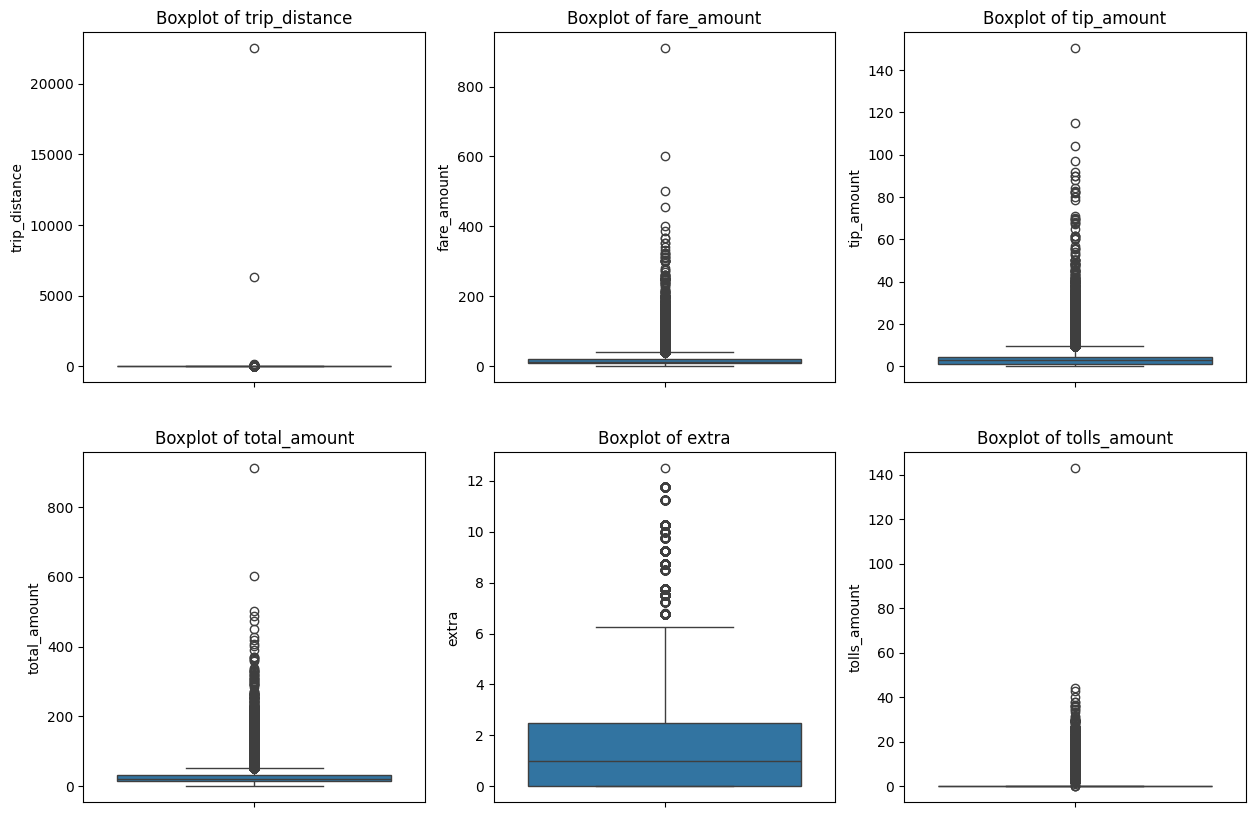

In [49]:
columns_to_check = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount','extra', 'tolls_amount']
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.show()

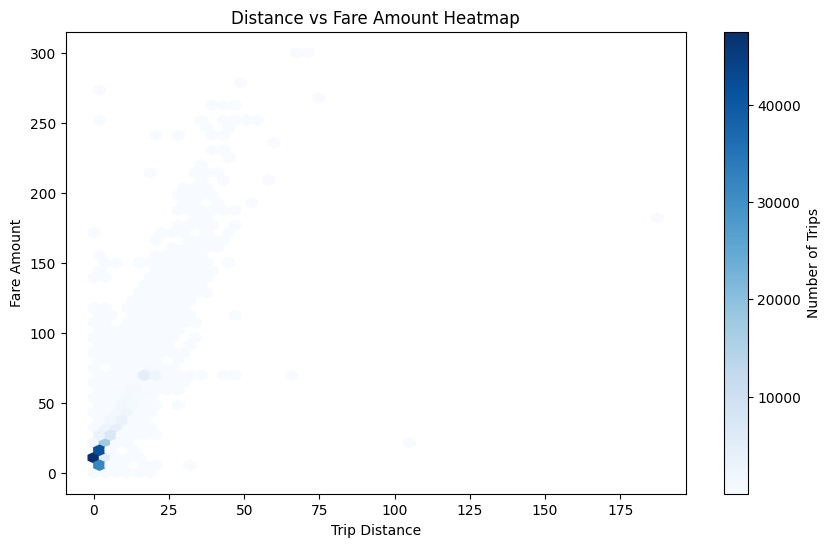

In [50]:
# distance vs fare amount
filtered_df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]
filtered_df = filtered_df[(filtered_df['trip_distance'] < 250) & (filtered_df['fare_amount'] <= 300)]  # filter out extreme outliers for better visualization

plt.figure(figsize=(10, 6))

plt.hexbin(
    filtered_df['trip_distance'],
    filtered_df['fare_amount'],
    gridsize=50,
    cmap='Blues',
    mincnt=1
)

plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Distance vs Fare Amount Heatmap')
plt.colorbar(label='Number of Trips')

plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [51]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]


In [52]:
# Continue with outlier handling
# remove distance = 0 and fare > 0
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# remove distance & fare = 0 and pickup and drop location different
df = df[
    ~((df['trip_distance'] == 0) &
      (df['fare_amount'] == 0) &
      (df['PULocationID'] != df['DOLocationID']))
]

# remove distance > 250
df = df[df['trip_distance'] <= 250]

# remove tip amount > 100
df = df[df['tip_amount'] <= 100]

# remove invalid payment types
df = df[df['payment_type'] != 0]

# remove fare amount = 0, but tip amount > 0
df = df[~((df['fare_amount'] == 0) & (df['tip_amount'] > 0))]
df['tip_percentage'] = df['tip_amount'] / df['fare_amount'] * 100
df = df[df['tip_percentage'] <= 100]

df['tip_amount'] = df['tip_amount'].clip(upper=100)


In [53]:
# Do any columns need standardising?

# No standardisation needed as this is an EDA-focused analysis
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined,tip_percentage
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,0.000000
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,32.658228
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,0.000000
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,0.000000
5,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,34.5,3.5,0.5,7.90,0.0,1.0,47.40,2.5,0.00,22.898551


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [54]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined',
 'tip_percentage']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Neither(This is temporal features used for time-based analysis)
* `tpep_dropoff_datetime`: Neither(This is temporal features used for time-based analysis)
* `passenger_count`: Categorical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

These belong to the Numerical category

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

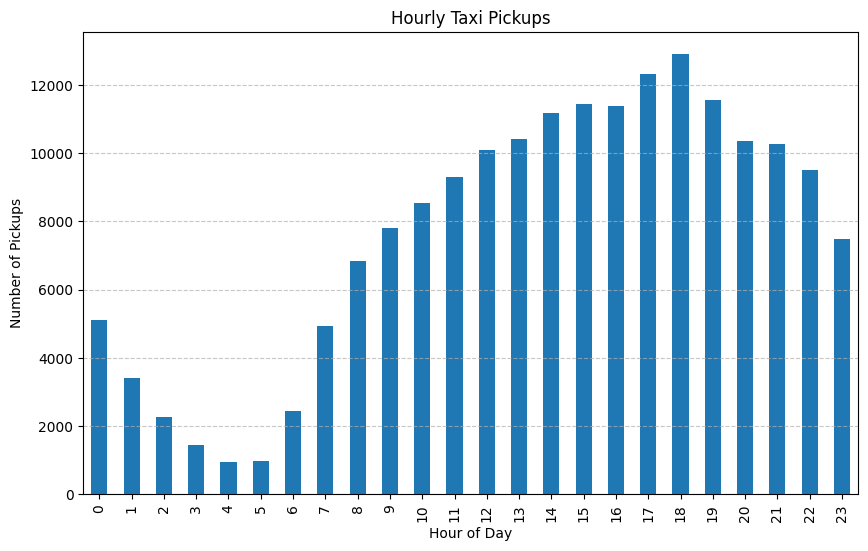

In [55]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_trends = df['pickup_hour'].value_counts().sort_index()

hourly_trends.plot(kind='bar', figsize=(10, 6), title='Hourly Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(24)) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


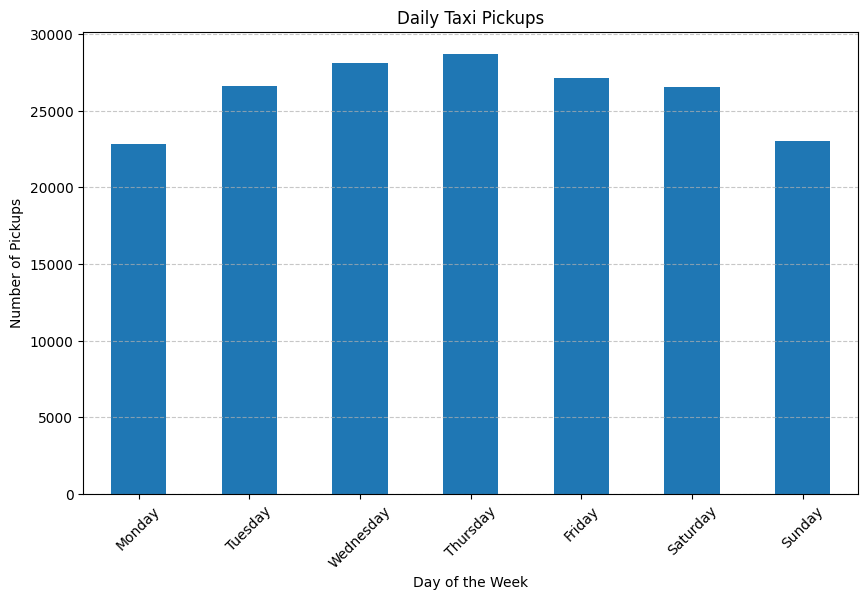

In [56]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trends = df['pickup_day'].value_counts().reindex(day_order)

daily_trends.plot(kind='bar', figsize=(10, 6), title='Daily Taxi Pickups')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


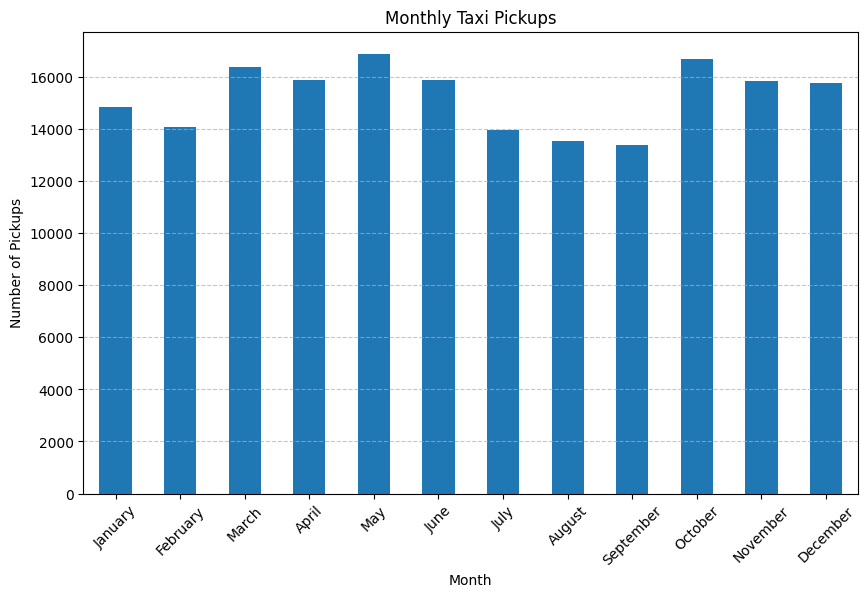

In [57]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_trends = df['pickup_month'].value_counts().reindex(months_order)

monthly_trends.plot(kind='bar', figsize=(10, 6), title='Monthly Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [58]:
# Analyse the above parameters
columns_to_analyse = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount']

for col in columns_to_analyse:
    print(f"Analysis of {col}:")
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())
    print("-"*30)



Analysis of trip_distance:
Zero values: 2177
Negative values: 0
------------------------------
Analysis of fare_amount:
Zero values: 0
Negative values: 0
------------------------------
Analysis of tip_amount:
Zero values: 40913
Negative values: 0
------------------------------
Analysis of total_amount:
Zero values: 0
Negative values: 0
------------------------------


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

It is not beneficial to remove all zero values from the dataset, as some of them represent valid scenarios like zero tips. However, selectively filtering records with zero trip distance may be useful in specific analyses where meaningful trip activity is required.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [59]:
# Create a df with non zero entries for the selected parameters.
df_filtered = df.copy()


df_filtered = df_filtered[~(
    (df_filtered['trip_distance'] != 0) &
    (df_filtered['fare_amount'] != 0) &
    (df_filtered['total_amount'] != 0)
)]

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

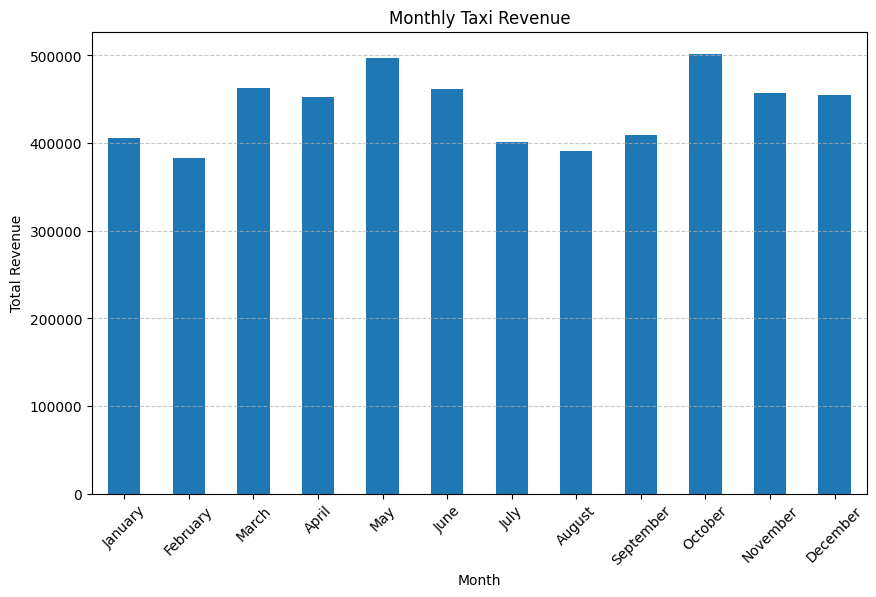

In [60]:
# Group data by month and analyse monthly revenue
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum().reindex(months_order)

monthly_revenue.plot(kind='bar', figsize=(10, 6), title='Monthly Taxi Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.to_period('Q')
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
quarterly_proportion

# visualise quarterly proportions
quarterly_proportion.plot(kind='bar', figsize=(10, 6), title='Quarterly Revenue Proportion')
plt.xlabel('Quarter')
plt.ylabel('Revenue Proportion (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

pickup_quarter
2023Q1    23.711956
2023Q2    26.727745
2023Q3    22.760281
2023Q4    26.800019
Freq: Q-DEC, Name: total_amount, dtype: float64

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

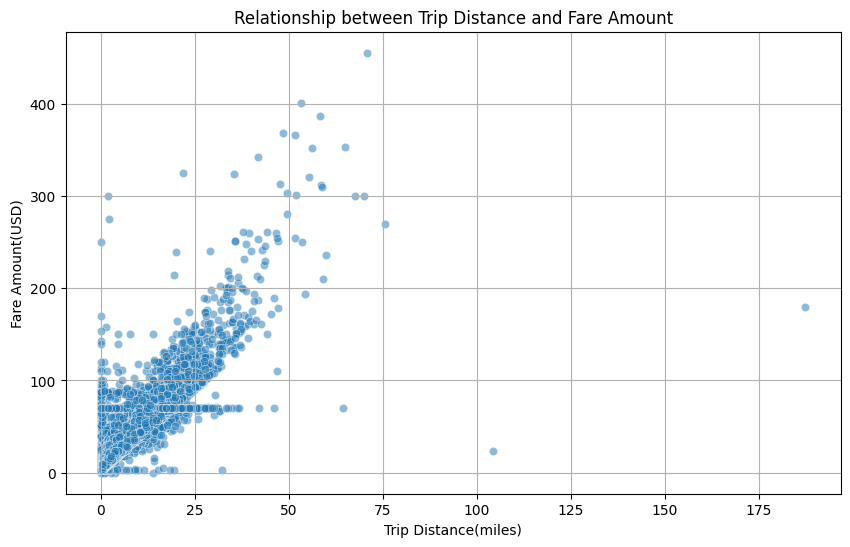

Correlation between trip distance and fare amount: 0.94


In [63]:
# Show how trip fare is affected by distance
filtered_df = df[(df['trip_distance'] > 0)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=filtered_df['trip_distance'], y=filtered_df['fare_amount'], data=filtered_df, alpha=0.5)
plt.xlabel('Trip Distance(miles)')
plt.ylabel('Fare Amount(USD)')
plt.title('Relationship between Trip Distance and Fare Amount')
plt.grid(True)
plt.show()

correlation = filtered_df['trip_distance'].corr(filtered_df['fare_amount'])
print(f"Correlation between trip distance and fare amount: {correlation:.2f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

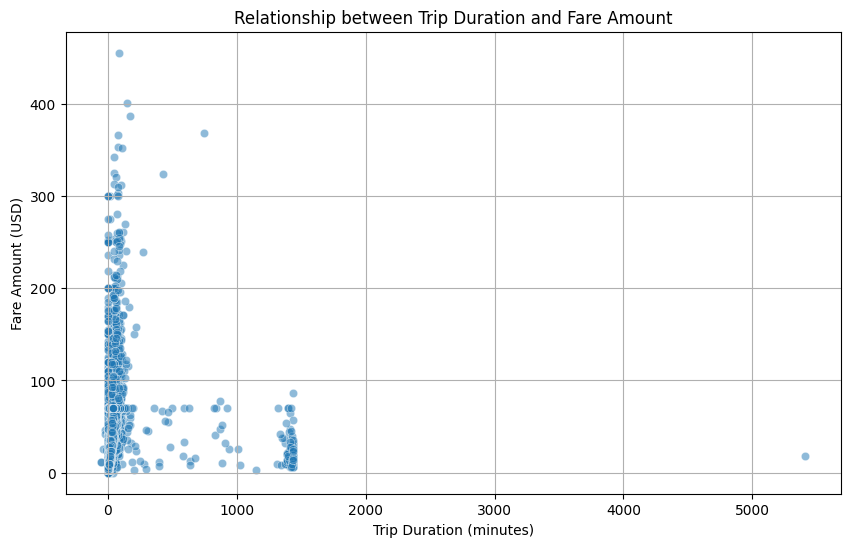

Correlation between trip duration and fare amount: 0.26


In [64]:
# Show relationship between fare and trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60  

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['trip_duration'], y=df['fare_amount'], data=df, alpha=0.5)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount (USD)')
plt.title('Relationship between Trip Duration and Fare Amount')
plt.grid(True)
plt.show()

correlation = df['trip_duration'].corr(df['fare_amount'])
print(f"Correlation between trip duration and fare amount: {correlation:.2f}")



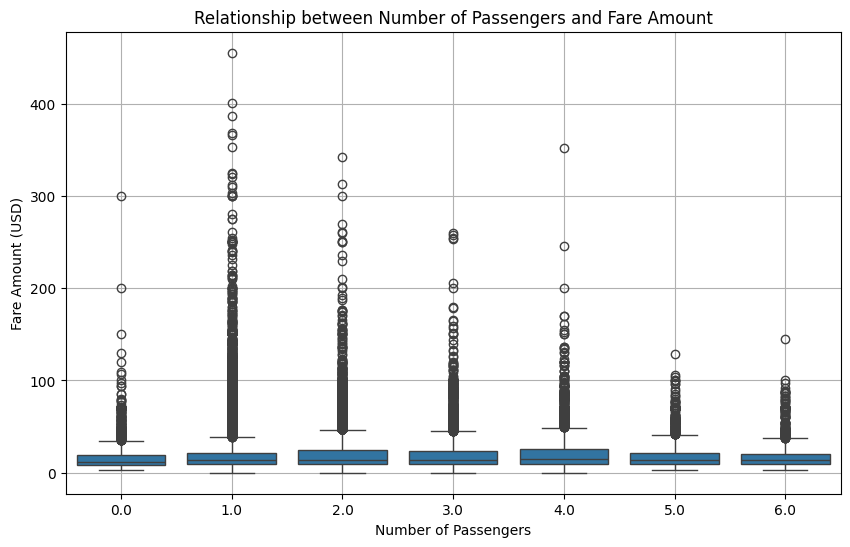

Correlation between passenger count and fare amount: 0.05


In [65]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['passenger_count'], y=df['fare_amount'], data=df)
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount (USD)')
plt.title('Relationship between Number of Passengers and Fare Amount')
plt.grid(True)
plt.show()

correlation = df['passenger_count'].corr(df['fare_amount'])
print(f"Correlation between passenger count and fare amount: {correlation:.2f}")


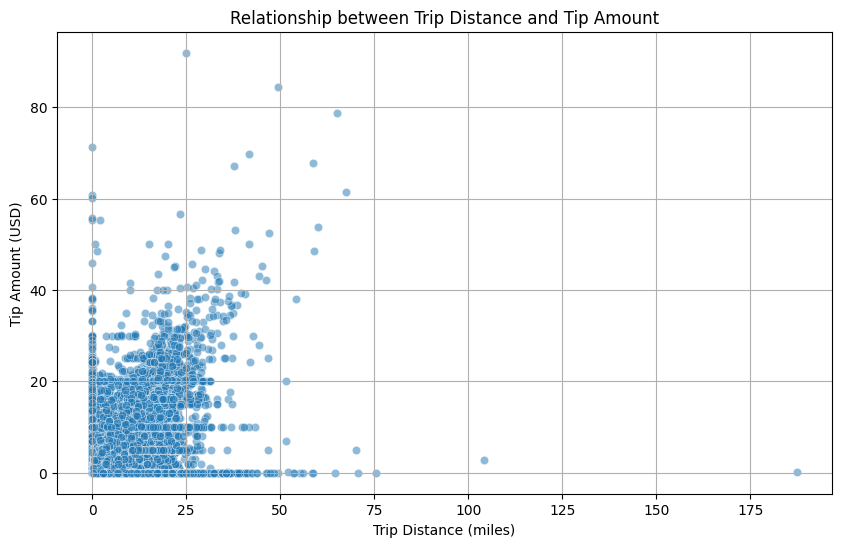

Correlation between trip distance and tip amount: 0.59


In [66]:
# Show relationship between tip and trip distance

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['trip_distance'], y=df['tip_amount'], data=df, alpha=0.5)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount (USD)')
plt.title('Relationship between Trip Distance and Tip Amount')
plt.grid(True)
plt.show()

correlation = df['trip_distance'].corr(df['tip_amount'])
print(f"Correlation between trip distance and tip amount: {correlation:.2f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

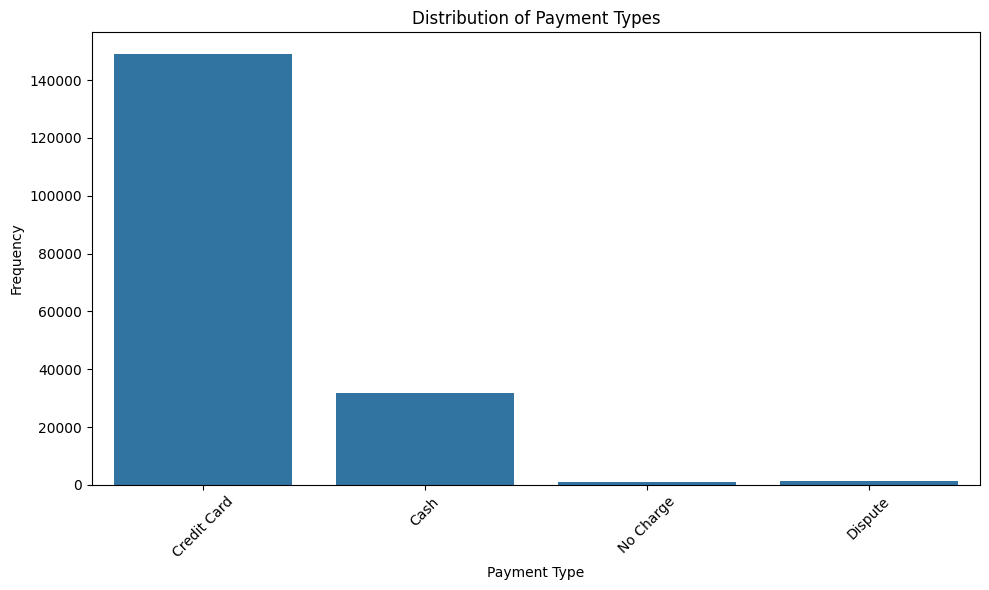

payment_type
1    81.458061
2    17.345015
3     0.462920
4     0.734004
Name: count, dtype: float64

In [67]:
# Analyse the distribution of different payment types (payment_type).
all_payment_types = [1, 2, 3, 4, 5, 6]
payment_type_labels = ["Credit Card", "Cash", "No Charge", "Dispute", "Unknown", "Voided Trip"]
payment_type_counts = df['payment_type'].value_counts().reindex(all_payment_types, fill_value=0)

payment_df = pd.DataFrame({
    'Payment Type': payment_type_labels,
    'Count': payment_type_counts.values
})

payment_df = payment_df[payment_df['Count'] > 0]  # filter out payment types that are not present in the data
plt.figure(figsize=(10, 6))
sns.barplot(x='Payment Type', y='Count', data=payment_df)
plt.xlabel('Payment Type')
plt.ylabel('Frequency')
plt.title('Distribution of Payment Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

payment_type_percentages = (payment_type_counts / payment_type_counts.sum()) * 100
non_zero_payment_types = payment_type_percentages[payment_type_percentages > 0]
non_zero_payment_types


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [68]:
!pip install geopandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [69]:
import geopandas as gpd

# Read the shapefile using geopandas
zones =gpd.read_file('taxi_zones//taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    str     
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    str     
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 18.5 KB


<Axes: >

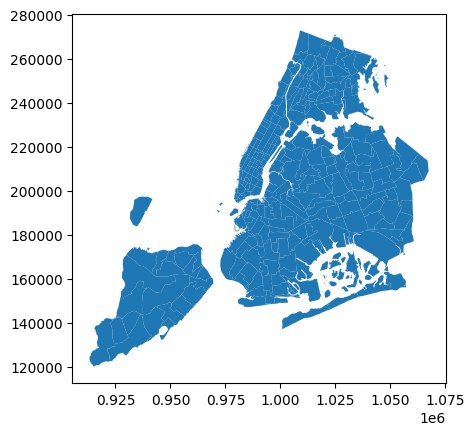

In [118]:
zones.info()
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [71]:
# Merge zones and trip records using locationID and PULocationID

merged_df = pd.merge(df, zones, left_on='PULocationID', right_on='LocationID', how='left')

merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_month,pickup_quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,January,2023Q1,15.950000,138.0,0.107467,0.000537,LaGuardia Airport,138.0,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,January,2023Q1,5.083333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,January,2023Q1,10.550000,237.0,0.042213,0.000096,Upper East Side South,237.0,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,January,2023Q1,5.416667,143.0,0.054180,0.000151,Lincoln Square West,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,January,2023Q1,33.616667,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [72]:
# Group data by location and calculate the number of trips
trip_counts_by_location = df.groupby('PULocationID').size().reset_index(name='trip_count')

trip_counts_by_location.head()


,PULocationID,trip_count
0,1,27
1,3,8
2,4,176
3,5,1
4,6,2


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [73]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_counts = pd.merge(zones, trip_counts_by_location, left_on='LocationID', right_on='PULocationID', how='left')

zones_with_counts.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,27.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,8.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,176.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,1.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

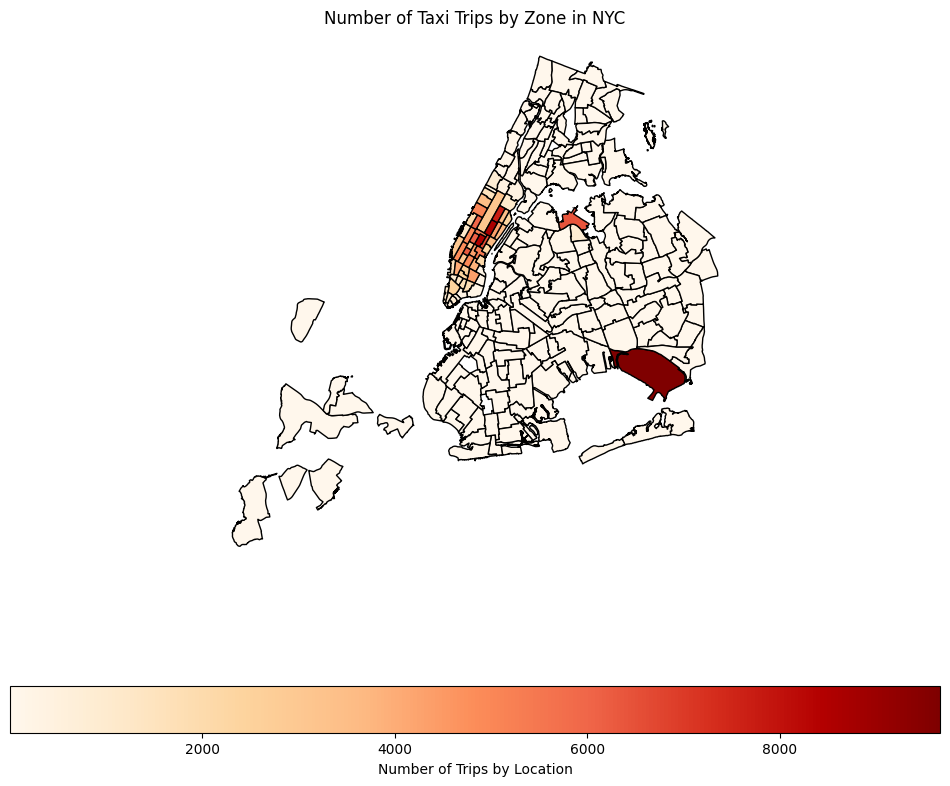

In [75]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_counts.plot(
    column='trip_count', 
    ax=ax, 
    legend=True, 
    legend_kwds={'label': "Number of Trips by Location", 
                 'orientation': "horizontal"},
    cmap='OrRd', 
    edgecolor='black')

# Plot the map and display it
ax.set_title('Number of Taxi Trips by Zone in NYC')
plt.axis('off')
plt.show()

In [ ]:
# displaying the zones DF sorted by the number of trips
zones_with_counts_sorted = zones_with_counts.sort_values(by='trip_count', ascending=False)
zones_with_counts_sorted.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,9665.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,8644.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,8516.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,7719.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,6616.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [77]:
# Find routes which have the slowest speeds at different times of the day
df_route = df[
    ['PULocationID', 'DOLocationID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance']
].copy()

df_route['trip_duration_hrs'] = (df_route['tpep_dropoff_datetime'] - df_route['tpep_pickup_datetime']).dt.total_seconds() / 3600

df_route = df_route[(df_route['trip_duration_hrs'] > 0) & (df_route['trip_distance'] > 0)]

df_route['pickup_hour'] = df_route['tpep_pickup_datetime'].dt.hour

grouped = df_route.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
speed_data = grouped.agg({
    'trip_distance': 'mean',
    'trip_duration_hrs': 'mean'
}).reset_index()
speed_data['average_speed_mph'] = speed_data['trip_distance'] / speed_data['trip_duration_hrs']

slowest_routes = speed_data.sort_values(by='average_speed_mph').head(10)
slowest_routes

,PULocationID,DOLocationID,pickup_hour,trip_distance,trip_duration_hrs,average_speed_mph
37618,226,145,18,1.200,45.165000,0.026569
51652,264,237,15,0.040,0.929444,0.043036
36428,209,232,13,1.040,23.864722,0.043579
4150,50,43,8,1.420,23.855556,0.059525
32179,164,100,21,0.790,11.647222,0.067827
18515,134,265,15,0.100,1.354444,0.073831
9600,88,144,0,1.780,23.757778,0.074923
37970,229,137,2,1.940,23.904167,0.081157
15521,128,128,7,0.020,0.173333,0.115385
1490,41,41,16,0.598,4.853389,0.123213


How does identifying high-traffic, high-demand routes help us? <br>
Identifying high-traffic, high-demand routes helps optimize driver allocation and availability, ensuring taxis are present where needed most. It also boosts revenue through targeted operations and dynamic pricing, improves customer wait times, and supports traffic and urban planning by highlighting congestion-prone areas.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

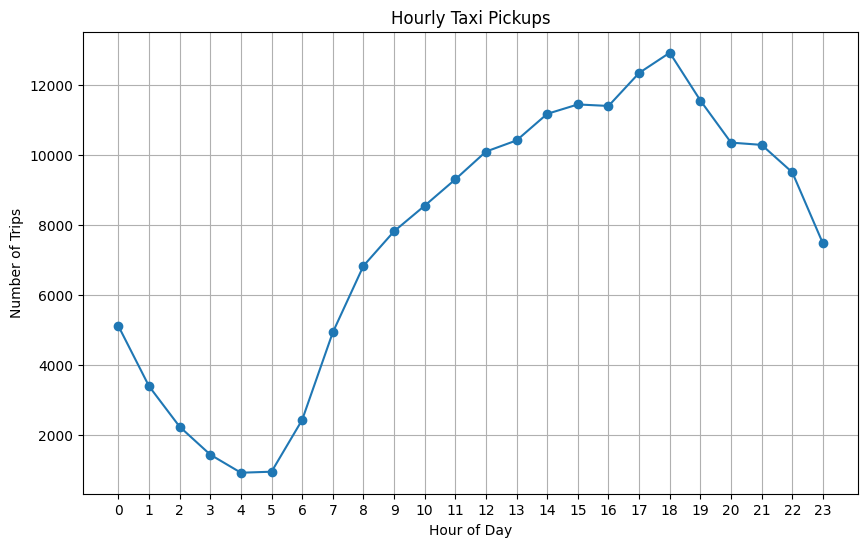

The busiest hour for taxi pickups is: 18 with 12918 trips.


In [78]:
# Visualise the number of trips per hour and find the busiest hour

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_trends = df.groupby('pickup_hour').size().reset_index(name='trip_count')

rush_hours = hourly_trends.loc[hourly_trends['trip_count'].idxmax()]

plt.figure(figsize=(10, 6))
plt.plot(hourly_trends['pickup_hour'], hourly_trends['trip_count'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Taxi Pickups')
plt.grid(True)
plt.xticks(range(24))
plt.show()

print(f"The busiest hour for taxi pickups is: {rush_hours['pickup_hour']} with {rush_hours['trip_count']} trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

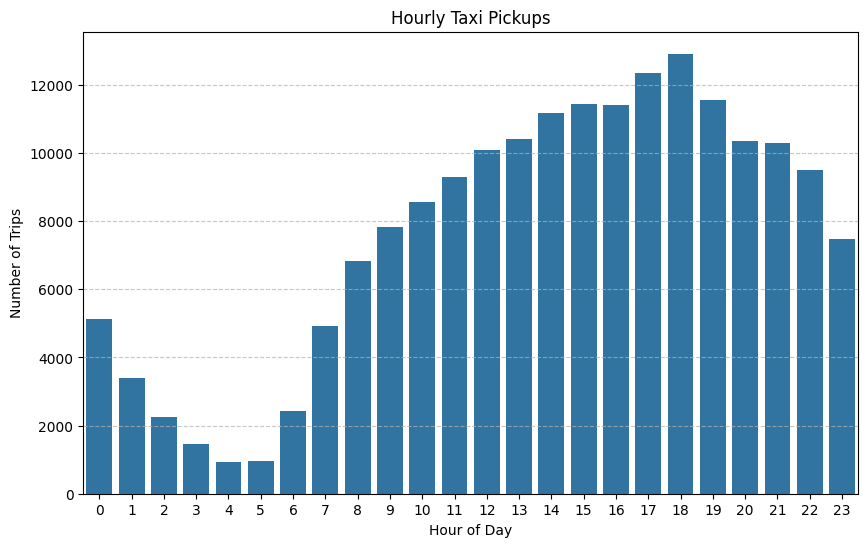

In [83]:
# extract the hour from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
trip_counts_by_hour = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=trip_counts_by_hour.index, y=trip_counts_by_hour.values)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Taxi Pickups')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [91]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.1

top5_hours = trip_counts_by_hour.sort_values(ascending=False).head(5)
scaled_top5_hours = (top5_hours / sample_fraction).astype(int)
scaled_top5_hours


pickup_hour
18    129180
17    123410
19    115540
15    114420
16    113990
Name: count, dtype: int64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

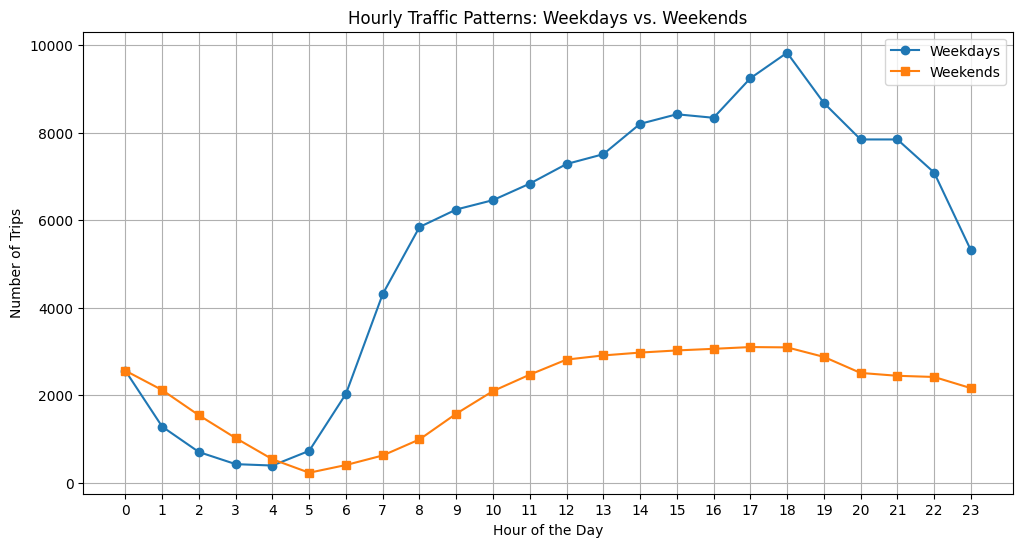

In [92]:
# Compare traffic trends for the week days and weekends

df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
weekdays_df = df[df['day_of_week'] < 5]  # Monday to Friday
weekends_df = df[df['day_of_week'] >= 5]  # Saturday and Sunday
weekday_hourly_counts = weekdays_df.groupby(weekdays_df['tpep_pickup_datetime'].dt.hour)['tpep_pickup_datetime'].count()
weekend_hourly_counts = weekends_df.groupby(weekends_df['tpep_pickup_datetime'].dt.hour)['tpep_pickup_datetime'].count()

plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly_counts.index, weekday_hourly_counts.values, label='Weekdays', marker='o')
plt.plot(weekend_hourly_counts.index, weekend_hourly_counts.values, label='Weekends', marker='s')
plt.title('Hourly Traffic Patterns: Weekdays vs. Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [95]:
# Find top 10 pickup and dropoff zones
top_pk = df['PULocationID'].value_counts().head(10).reset_index()
top_pk.columns = ['LocationID', 'Pickup_Trips']

# Merge with zones to get zone names
top_pk = top_pk.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
print("Top 10 Pickup Zones:")
top_pk

Top 10 Pickup Zones:


,LocationID,Pickup_Trips,zone
0,132,9665,JFK Airport
1,237,8644,Upper East Side South
2,161,8516,Midtown Center
3,236,7719,Upper East Side North
4,162,6616,Midtown East
5,138,6409,LaGuardia Airport
6,186,6269,Penn Station/Madison Sq West
7,230,6080,Times Sq/Theatre District
8,142,5998,Lincoln Square East
9,170,5375,Murray Hill


In [94]:
# Dropoff zones
top_drop = df['DOLocationID'].value_counts().head(10).reset_index()
top_drop.columns = ['LocationID', 'Dropoff_Trips']

# Merge with zones
top_drop = top_drop.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
top_drop


,LocationID,Dropoff_Trips,zone
0,236,8231,Upper East Side North
1,237,7651,Upper East Side South
2,161,7165,Midtown Center
3,230,5614,Times Sq/Theatre District
4,170,5446,Murray Hill
5,142,5243,Lincoln Square East
6,162,5185,Midtown East
7,239,5034,Upper West Side South
8,141,4786,Lenox Hill West
9,68,4690,East Chelsea


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [111]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df['PULocationID'].value_counts().rename('pickup_count')
dropoff_counts = df['DOLocationID'].value_counts().rename('dropoff_count')

ratios = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)
ratios['pickup_dropoff_ratio'] = ratios['pickup_count'] / ratios['dropoff_count'].replace(0, np.nan)

ratios = ratios.reset_index().rename(columns={'index': 'LocationID'})
ratios = ratios.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
ratios = ratios.set_index('zone')

top_pickup_dropoff_ratio = ratios[['pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']].sort_values('pickup_dropoff_ratio', ascending=False).head(10)
bottom_pickup_dropoff_ratio = ratios[['pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']].sort_values('pickup_dropoff_ratio', ascending=True).head(10)


In [112]:
top_pickup_dropoff_ratio

,pickup_count,dropoff_count,pickup_dropoff_ratio
zone,,,
East Elmhurst,847.0,108,7.842593
JFK Airport,9665.0,2055,4.703163
LaGuardia Airport,6409.0,2189,2.927821
Penn Station/Madison Sq West,6269.0,4165,1.505162
West Village,4076.0,2972,1.371467
Central Park,3111.0,2290,1.358515
Greenwich Village South,2392.0,1768,1.352941
Midtown East,6616.0,5185,1.275988
Hollis,10.0,8,1.250000


In [113]:
bottom_pickup_dropoff_ratio

,pickup_count,dropoff_count,pickup_dropoff_ratio
zone,,,
Highbridge Park,0.0,8,0.0
Heartland Village/Todt Hill,0.0,8,0.0
Bronx Park,0.0,12,0.0
Glen Oaks,0.0,16,0.0
Ocean Parkway South,0.0,13,0.0
Saint George/New Brighton,0.0,3,0.0
Rossville/Woodrow,0.0,3,0.0
West Brighton,0.0,2,0.0
Broad Channel,0.0,2,0.0


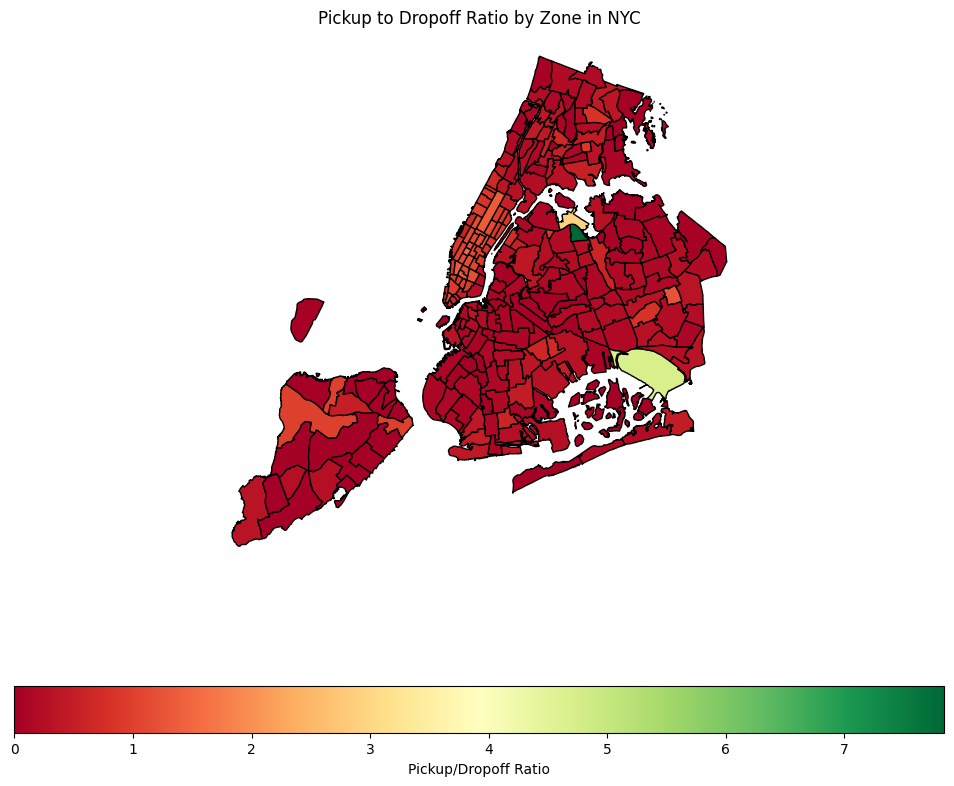

In [117]:
# visualization of zones with highest and lowest pickup/dropoff ratios
zones_with_ratios = zones.merge(
    ratios[['LocationID', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']],
    left_on='LocationID', 
    right_on='LocationID', 
    how='left')

# fill NaN values in pickup_dropoff_ratio with 0 for better visualization
zones_with_ratios['pickup_dropoff_ratio'] = zones_with_ratios['pickup_dropoff_ratio'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_ratios.plot(
    column='pickup_dropoff_ratio', 
    ax=ax, 
    legend=True, 
    legend_kwds={'label': "Pickup/Dropoff Ratio", 'orientation': "horizontal"},
    cmap='RdYlGn', 
    edgecolor='black')
ax.set_title('Pickup to Dropoff Ratio by Zone in NYC')
plt.axis('off')
plt.show()



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [119]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_hours_df = df[(df['tpep_pickup_datetime'].dt.hour>= 23) | (df['tpep_pickup_datetime'].dt.hour <= 5)]
night_hours_df = night_hours_df.merge(
    zones[['LocationID', 'zone']].rename(columns={'zone': 'pickup_zone'}), 
    left_on='PULocationID', 
    right_on='LocationID', 
    how='left'
)

night_hours_df = night_hours_df.merge(
    zones[['LocationID', 'zone']].rename(columns={'zone': 'dropoff_zone'}), 
    left_on='DOLocationID', 
    right_on='LocationID', 
    how='left'
)

top_night_pickup_zones = night_hours_df.groupby('pickup_zone')['PULocationID'].count().sort_values(ascending=False).head(10)
top_night_dropoff_zones = night_hours_df.groupby('dropoff_zone')['DOLocationID'].count().sort_values(ascending=False).head(10)

In [127]:
top_night_pickup_zones

pickup_zone
East Village                    1581
JFK Airport                     1451
West Village                    1263
Clinton East                    1021
Lower East Side                  988
Times Sq/Theatre District        866
Greenwich Village South          863
Penn Station/Madison Sq West     708
LaGuardia Airport                621
Midtown South                    607
Name: PULocationID, dtype: int64

In [121]:
top_night_dropoff_zones

dropoff_zone
East Village             832
Clinton East             697
Murray Hill              616
East Chelsea             593
Gramercy                 582
Yorkville West           530
Lenox Hill West          527
West Village             491
Upper East Side North    460
Flatiron                 454
Name: DOLocationID, dtype: int64

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [122]:
# Filter for night hours (11 PM to 5 AM)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

nighttime_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]
daytime_df = df[(df['pickup_hour'] >= 6) & (df['pickup_hour'] <= 22)]

nighttime_revenue = nighttime_df['total_amount'].sum()
daytime_revenue = daytime_df['total_amount'].sum()

print(f"Total revenue during nighttime hours: ${nighttime_revenue:,.2f}")
print(f"Total revenue during daytime hours: ${daytime_revenue:,.2f}")

total_revenue = df['total_amount'].sum()
nighttime_proportion = (nighttime_revenue / total_revenue) * 100
daytime_proportion = (daytime_revenue / total_revenue) * 100

print(f"Proportion of revenue during nighttime hours: {nighttime_proportion:.2f}%")
print(f"Proportion of revenue during daytime hours: {daytime_proportion:.2f}%")

Total revenue during nighttime hours: $637,006.39
Total revenue during daytime hours: $4,639,852.11
Proportion of revenue during nighttime hours: 12.07%
Proportion of revenue during daytime hours: 87.93%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [126]:
# Analyse the fare per mile per passenger for different passenger counts
valid_trips = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)]

valid_trips['fare_per_mile_per_passenger'] = valid_trips['total_amount'] / valid_trips['trip_distance'] / valid_trips['passenger_count']
avg_fare_per_mile = valid_trips.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
avg_fare_per_mile

passenger_count
1.0    16.185845
2.0     8.814724
3.0     6.127407
4.0     6.244617
5.0     2.578923
6.0     2.099343
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [133]:
# Compare the average fare per mile for different days and for different times of the day
valid_trips = df[(df['trip_distance'] > 0)].copy()

valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

valid_trips['day_of_week'] = valid_trips['tpep_pickup_datetime'].dt.day_name()
valid_trips['hour_of_day'] = valid_trips['tpep_pickup_datetime'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_fare_by_day = valid_trips.groupby('day_of_week')['fare_per_mile'].mean().reindex(day_order)
avg_fare_by_hour = valid_trips.groupby('hour_of_day')['fare_per_mile'].mean().reindex(range(24))

avg_fare_by_day = avg_fare_by_day.reindex(day_order)
avg_fare_by_day

day_of_week
Monday        8.818724
Tuesday      10.108905
Wednesday    11.181354
Thursday     12.387639
Friday       10.012441
Saturday     11.948051
Sunday       11.264380
Name: fare_per_mile, dtype: float64

In [135]:
avg_fare_by_hour

hour_of_day
0     10.624813
1      9.925617
2      9.846365
3     10.619751
4     18.644502
5      9.581345
6     15.390914
7      7.576611
8      8.629300
9     10.275787
10    11.081052
11    11.736037
12    11.542412
13    13.143420
14    12.284581
15    10.879364
16    11.058380
17    11.350767
18    10.070582
19    12.885288
20     9.475615
21     8.404628
22     9.924966
23    10.601102
Name: fare_per_mile, dtype: float64

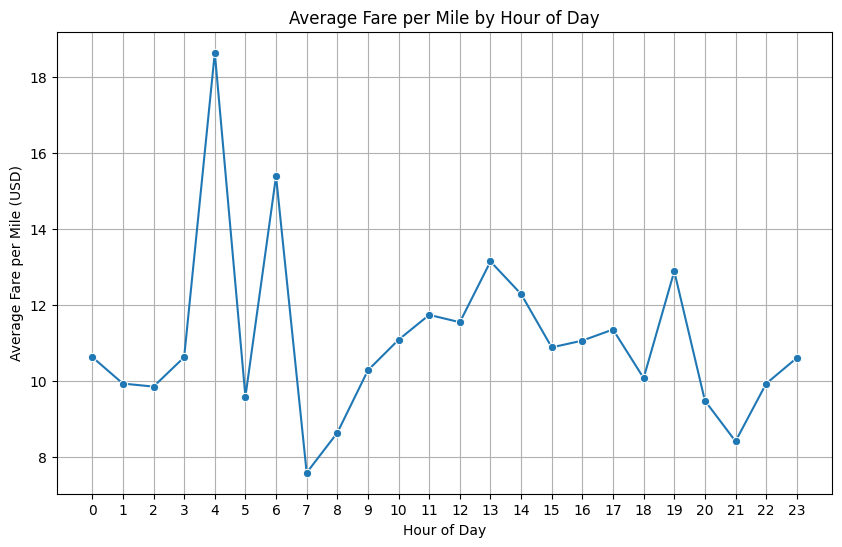

In [136]:
# visualise average fare per mile by hour
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_fare_by_hour.index, y=avg_fare_by_hour.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile (USD)')
plt.title('Average Fare per Mile by Hour of Day')
plt.xticks(range(24))
plt.grid(True)
plt.show()

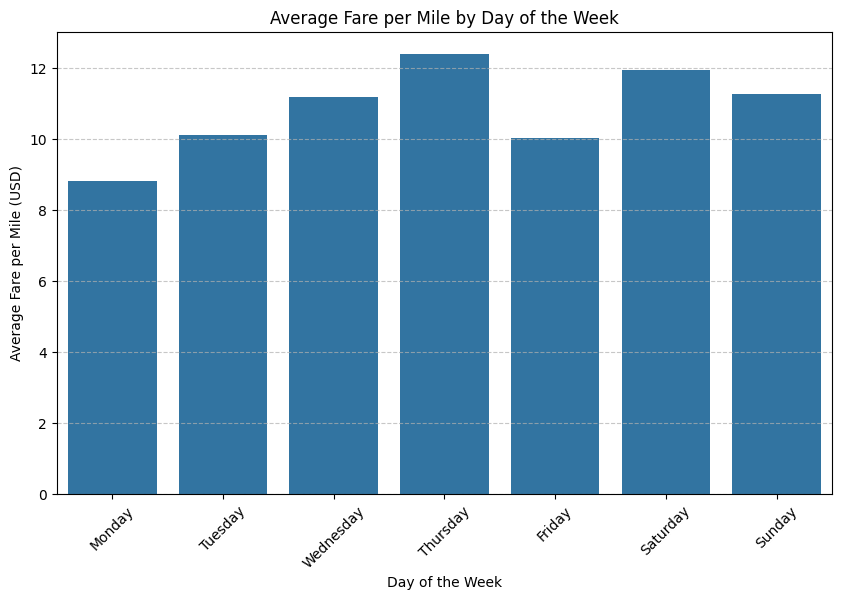

In [134]:
# visualise average fare per mile by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_fare_by_day.index, y=avg_fare_by_day.values)
plt.xlabel('Day of the Week')
plt.ylabel('Average Fare per Mile (USD)')
plt.title('Average Fare per Mile by Day of the Week')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [137]:
# Compare fare per mile for different vendors

df_vendor = df[df['trip_distance'] > 0].copy()
df_vendor['fare_per_mile'] = df_vendor['fare_amount'] / df_vendor['trip_distance']

vendor_fare_comparison = df_vendor.groupby('VendorID')['fare_per_mile'].mean().sort_values()
vendor_fare_comparison

VendorID
1     7.992295
2    11.891097
Name: fare_per_mile, dtype: float64

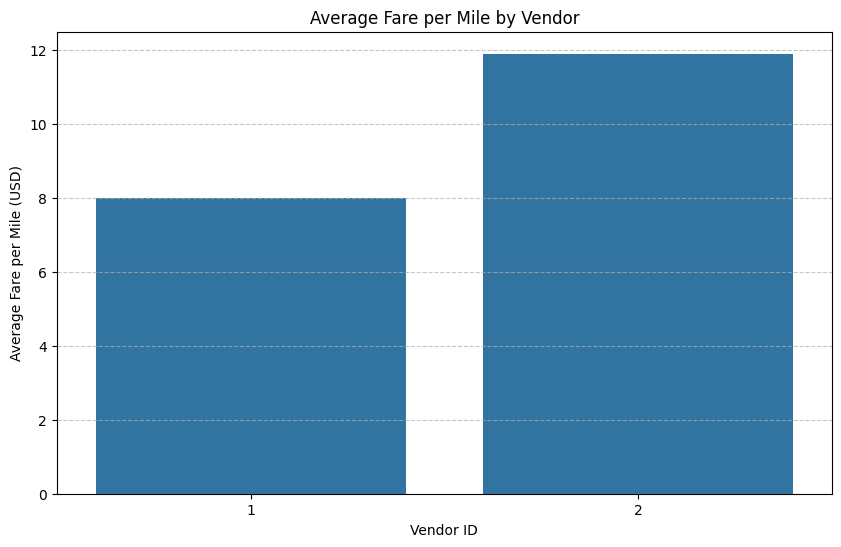

In [138]:
# visualization of fare per mile by vendor
plt.figure(figsize=(10, 6))
sns.barplot(x=vendor_fare_comparison.index, y=vendor_fare_comparison.values)
plt.xlabel('Vendor ID')
plt.ylabel('Average Fare per Mile (USD)')
plt.title('Average Fare per Mile by Vendor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [139]:
# Defining distance tiers
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']
df = df[df['trip_distance'] > 0] 

tier1 = df[df['trip_distance'] < 2].copy()
tier2 = df[(df['trip_distance'] >= 2) & (df['trip_distance'] <= 5)].copy()
tier3 = df[df['trip_distance'] > 5].copy()

tier1['distance_tier'] = 'Short (<2 miles)'
tier2['distance_tier'] = 'Medium (2-5 miles)'
tier3['distance_tier'] = 'Long (>5 miles)'

tier_wise_data = pd.concat([tier1, tier2, tier3])
avg_fare_by_tier = tier_wise_data.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()

avg_fare_by_tier


VendorID,1,2
distance_tier,,
Long (>5 miles),4.412686,4.501479
Medium (2-5 miles),6.448571,6.552026
Short (<2 miles),9.819382,17.038258


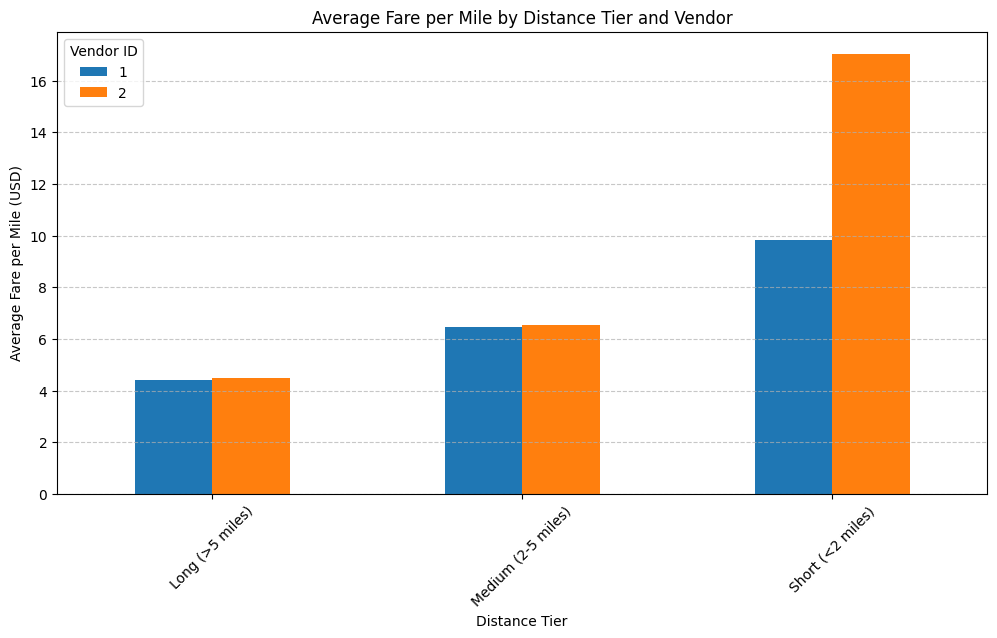

In [140]:
# visualize average fare per mile by distance tier and vendor
avg_fare_by_tier.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile (USD)')
plt.title('Average Fare per Mile by Distance Tier and Vendor')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Vendor ID')
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Average Tip Percentage by Distance Tier: distance_tier
Short (<2 miles)      22.145408
Medium (2-5 miles)    18.609007
Long (>5 miles)       16.478440
Name: tip_percentage, dtype: float64
Average Tip Percentage by Passenger Count: passenger_count
0.0    19.524313
1.0    20.477742
2.0    19.499024
3.0    19.015451
4.0    17.331361
5.0    20.669552
6.0    20.846001
Name: tip_percentage, dtype: float64
Average Tip Percentage by Time of Day: time_of_day
Afternoon    19.211870
Evening      21.784124
Morning      19.180279
Night        20.717882
Name: tip_percentage, dtype: float64


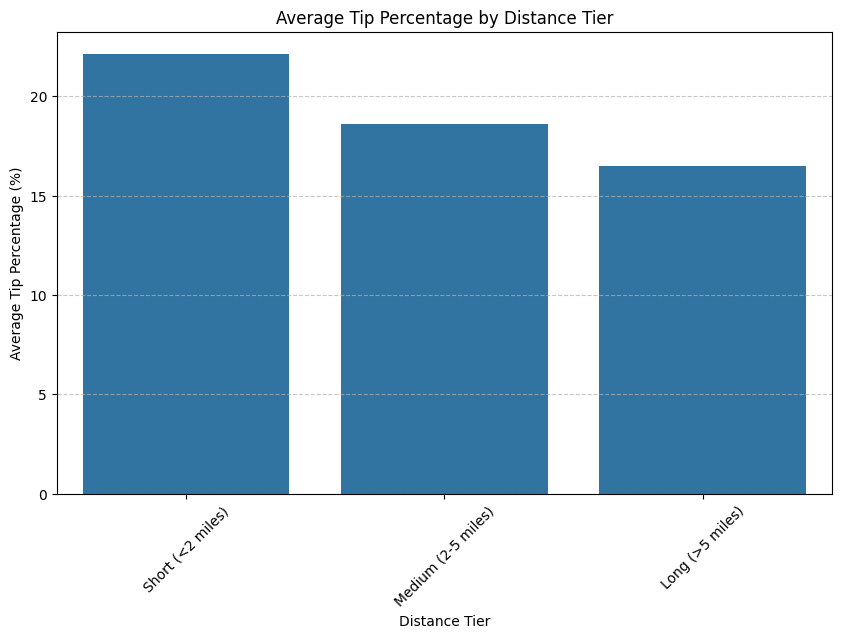

In [154]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df = df[df['fare_amount'] > 0].copy() 
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100

# Tip percentage by distance
df['distance_tier'] = pd.cut(df['trip_distance'],
    bins=[0, 2, 5, np.inf], 
    labels=['Short (<2 miles)', 'Medium (2-5 miles)', 'Long (>5 miles)'
    ])
tip_by_distance = df.groupby('distance_tier')['tip_percentage'].mean()
print(f"Average Tip Percentage by Distance Tier: {tip_by_distance}")

# Tip percentage by passenger count
tip_by_passenger_count = df.groupby('passenger_count')['tip_percentage'].mean()
print(f"Average Tip Percentage by Passenger Count: {tip_by_passenger_count}")

# Tip percentage by pickup hour
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'
    
df['time_of_day'] = df['pickup_hour'].apply(get_time_of_day)
tip_by_time_of_day = df.groupby('time_of_day')['tip_percentage'].mean()
print(f"Average Tip Percentage by Time of Day: {tip_by_time_of_day}")

# visualize tip percentage by distance tier
plt.figure(figsize=(10, 6))
sns.barplot(x=tip_by_distance.index, y=tip_by_distance.values)
plt.xlabel('Distance Tier')
plt.ylabel('Average Tip Percentage (%)')
plt.title('Average Tip Percentage by Distance Tier')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


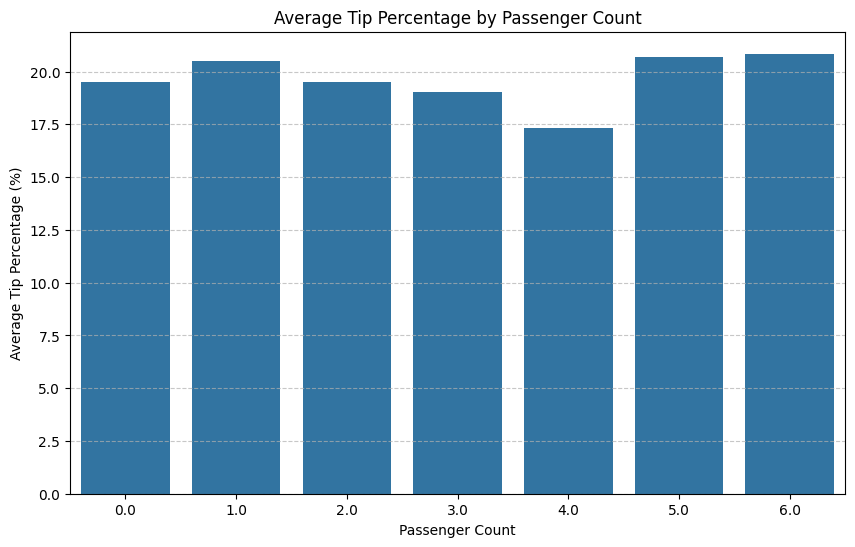

In [155]:
# visualise tip percentage by passenger count
plt.figure(figsize=(10, 6))
sns.barplot(x=tip_by_passenger_count.index, y=tip_by_passenger_count.values)
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Percentage (%)')
plt.title('Average Tip Percentage by Passenger Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

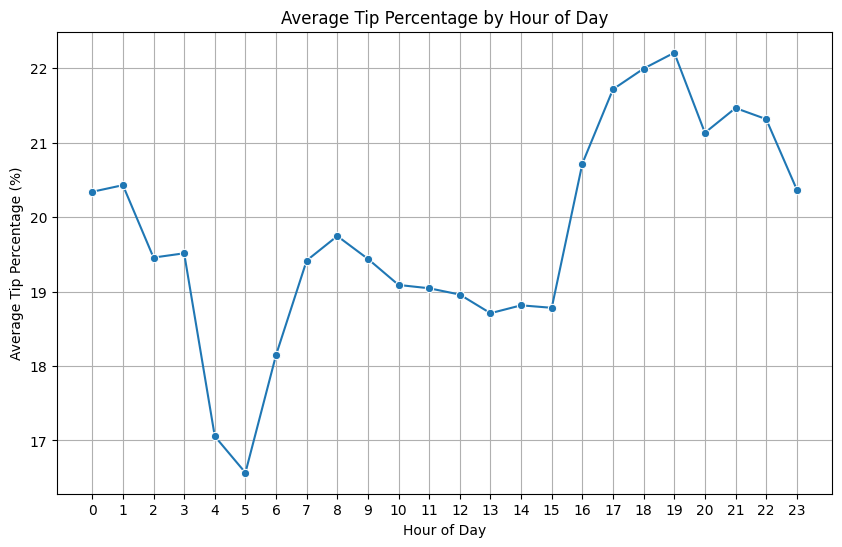

In [157]:
# visualise tip percentage by hour of the day
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
tip_by_hour = df.groupby('pickup_hour')['tip_percentage'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=tip_by_hour.index, y=tip_by_hour.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage (%)')
plt.title('Average Tip Percentage by Hour of Day')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [148]:
# low tip percentage analysis
low_tip = df[df['tip_percentage'] < 10]
print("Low Tip Percentage Analysis:")

# by distance tier
low_tip_by_distance = low_tip.groupby('distance_tier')['tip_percentage'].mean()
print(f"Low Tip Percentage by Distance Tier: {low_tip_by_distance}")
# by passenger count
low_tip_by_passenger_count = low_tip.groupby('passenger_count')['tip_percentage'].mean()
print(f"Low Tip Percentage by Passenger Count: {low_tip_by_passenger_count}")
# by time of day
low_tip_by_time_of_day = low_tip.groupby('time_of_day')['tip_percentage'].mean()
print(f"Low Tip Percentage by Time of Day: {low_tip_by_time_of_day}")

Low Tip Percentage Analysis:
Low Tip Percentage by Distance Tier: distance_tier
Short (<2 miles)      0.761514
Medium (2-5 miles)    1.625402
Long (>5 miles)       1.240017
Name: tip_percentage, dtype: float64
Low Tip Percentage by Passenger Count: passenger_count
0.0    0.877608
1.0    1.148871
2.0    0.979188
3.0    0.819772
4.0    0.634394
5.0    1.059008
6.0    1.292890
Name: tip_percentage, dtype: float64
Low Tip Percentage by Time of Day: time_of_day
Afternoon    0.945177
Evening      1.162008
Morning      1.028748
Night        1.298046
Name: tip_percentage, dtype: float64


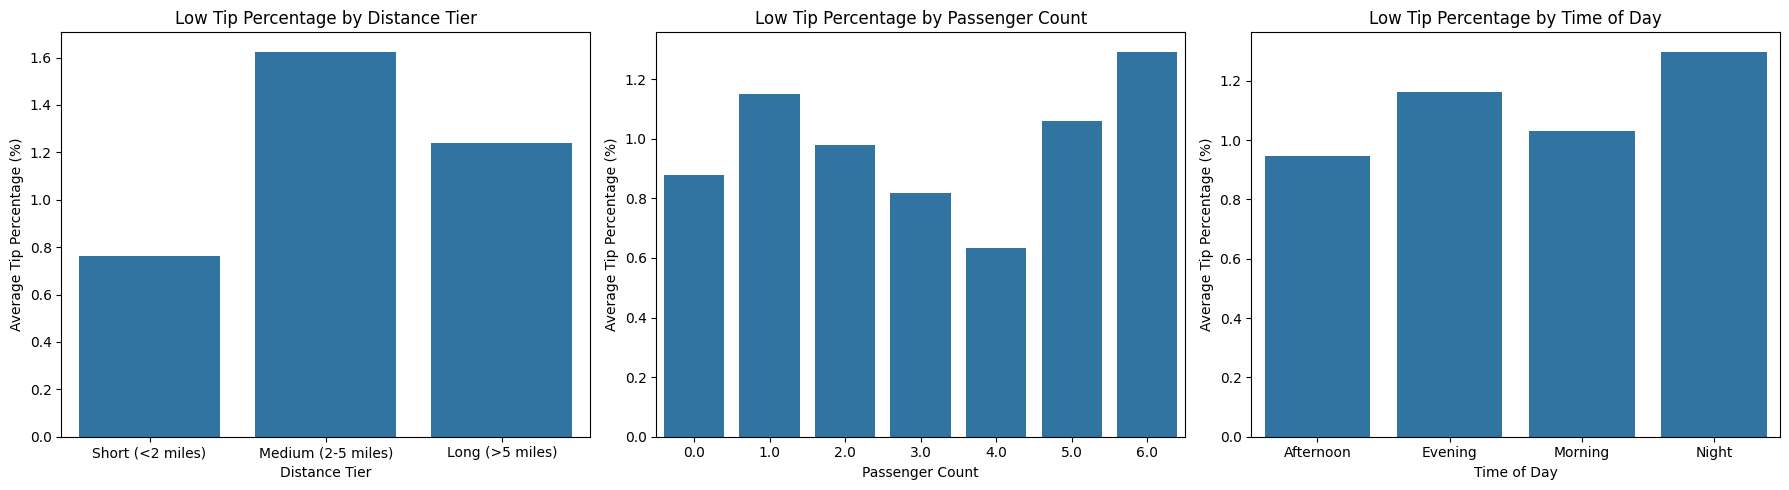

In [149]:
# visualise low tip percentage analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=low_tip_by_distance.index, y=low_tip_by_distance.values, ax=axes[0])
axes[0].set_title('Low Tip Percentage by Distance Tier')
axes[0].set_xlabel('Distance Tier')
axes[0].set_ylabel('Average Tip Percentage (%)')
sns.barplot(x=low_tip_by_passenger_count.index, y=low_tip_by_passenger_count.values, ax=axes[1])
axes[1].set_title('Low Tip Percentage by Passenger Count')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Average Tip Percentage (%)')
sns.barplot(x=low_tip_by_time_of_day.index, y=low_tip_by_time_of_day.values, ax=axes[2])
axes[2].set_title('Low Tip Percentage by Time of Day')
axes[2].set_xlabel('Time of Day')
axes[2].set_ylabel('Average Tip Percentage (%)')
plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [158]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100
low_tip_trips = df[df['tip_percentage'] < 10].copy()
high_tip_trips = df[df['tip_percentage'] > 25].copy()

comparison_metrics = pd.DataFrame({
    'Low Tip (<10%)': [
        low_tip_trips['trip_distance'].mean(),
        low_tip_trips['passenger_count'].mean(),
        low_tip_trips['fare_amount'].mean(),
        low_tip_trips['tip_amount'].mean()
    ],
    'High Tip (>25%)': [
        high_tip_trips['trip_distance'].mean(),
        high_tip_trips['passenger_count'].mean(),
        high_tip_trips['fare_amount'].mean(),
        high_tip_trips['tip_amount'].mean()
    ]
}, 
index=['Average Trip Distance', 'Average Passenger Count', 'Average Fare Amount', 'Average Tip Amount'])
print("Comparison of Low Tip and High Tip Trips:")
print(comparison_metrics)

Comparison of Low Tip and High Tip Trips:
                         Low Tip (<10%)  High Tip (>25%)
Average Trip Distance          3.905591         2.297868
Average Passenger Count        1.405673         1.348777
Average Fare Amount           21.478685        14.391030
Average Tip Amount             0.270471         4.378696


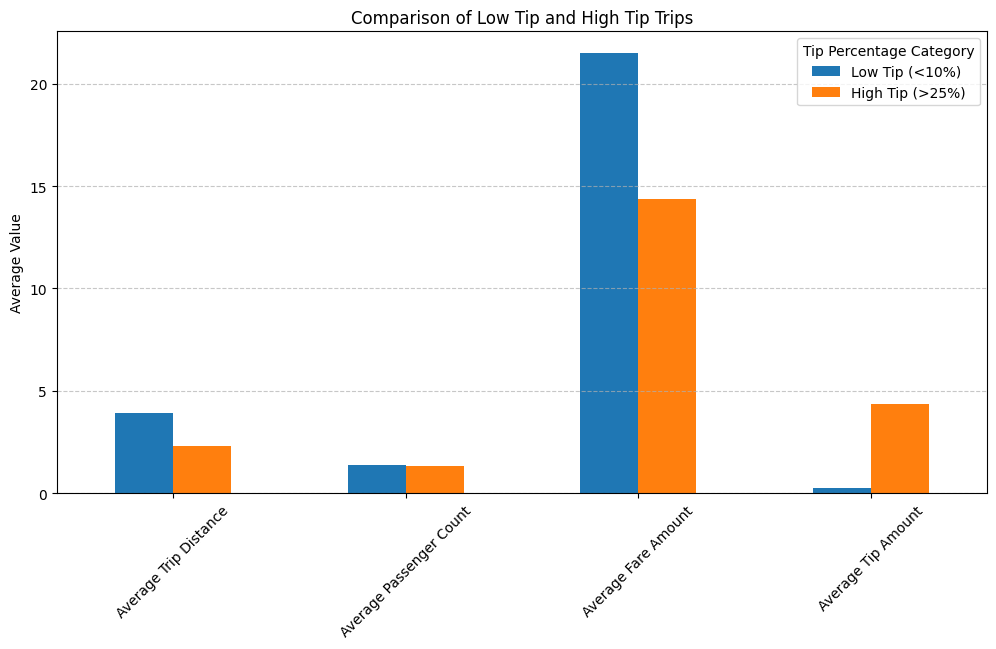

In [159]:
# visualize the comparison of low tip and high tip trips
comparison_metrics.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Low Tip and High Tip Trips')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tip Percentage Category')
plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

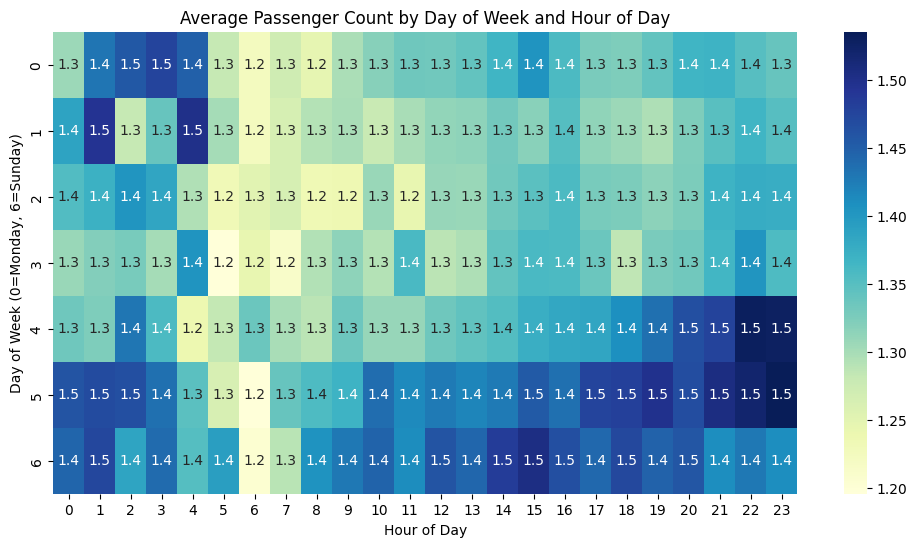

In [160]:
# See how passenger count varies across hours and days
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

passenger_count_variation = df.groupby(['pickup_day_of_week', 'pickup_hour'])['passenger_count'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(passenger_count_variation, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average Passenger Count by Day of Week and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
plt.show()



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [163]:
# How does passenger count vary across zones
zone_passenger_count_avg = df.groupby('PULocationID')['passenger_count'].mean().reset_index()

zone_passenger_count_avg = zone_passenger_count_avg.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
zone_passenger_count_avg = zone_passenger_count_avg.sort_values(by='passenger_count', ascending=False).head(20)
zone_passenger_count_avg

,PULocationID,passenger_count,LocationID,zone
60,67,2.333333,67.0,Dyker Heights
57,64,2.000000,64.0,Douglaston
4,6,2.000000,6.0,Arrochar/Fort Wadsworth
153,175,2.000000,175.0,Oakland Gardens
169,196,2.000000,196.0,Rego Park
134,154,2.000000,154.0,Marine Park/Floyd Bennett Field
136,157,1.888889,157.0,Maspeth
168,195,1.850000,195.0,Red Hook
9,12,1.800000,12.0,Battery Park
0,1,1.750000,1.0,Newark Airport


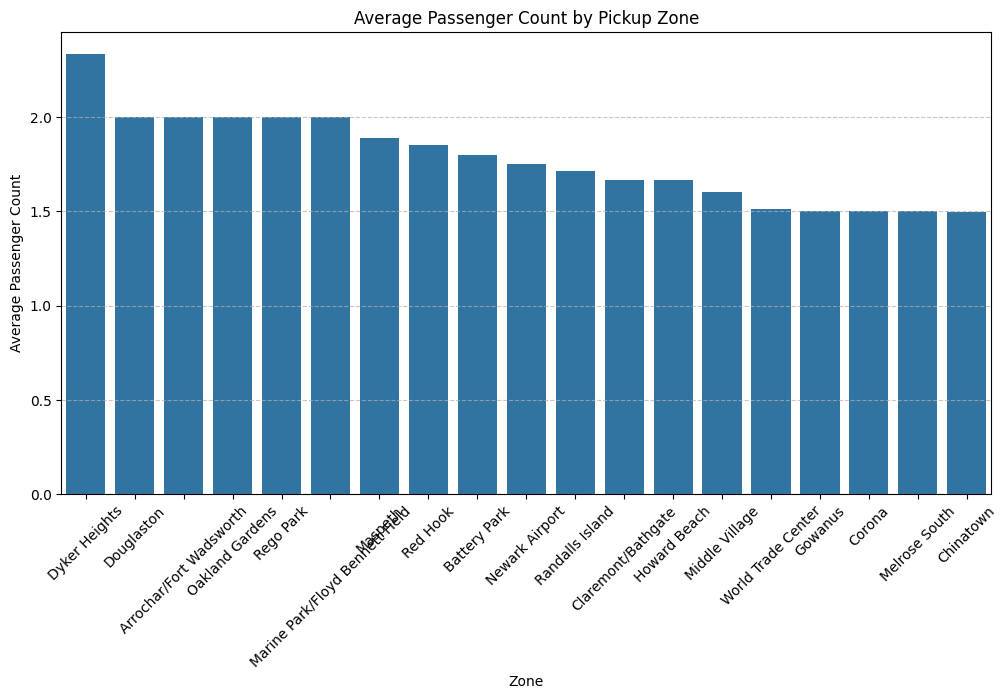

In [164]:
# visualize variation of passenger count across zones
plt.figure(figsize=(12, 6))
sns.barplot(x='zone', y='passenger_count', data=zone_passenger_count_avg)
plt.xlabel('Zone')
plt.ylabel('Average Passenger Count')
plt.title('Average Passenger Count by Pickup Zone')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [165]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips = zones.merge(
    df.groupby('PULocationID')['passenger_count'].mean().reset_index(), 
    left_on='LocationID', 
    right_on='PULocationID', 
    how='left'
)
zones_with_trips.rename(columns={'passenger_count': 'avg_passenger_count'}, inplace=True)
zones_with_trips.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,1.750000
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,1.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1.381503
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [166]:
# How often is each surcharge applied?
surcharge_columns = ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge']
surcharge_freq = df[surcharge_columns].astype(bool).sum() / len(df) * 100
print(f"Frequency of Surcharges Applied (% of Trips):\n{surcharge_freq}")


Frequency of Surcharges Applied (% of Trips):
extra                    62.174764
mta_tax                  99.408160
tip_amount               78.119054
tolls_amount              8.104341
improvement_surcharge    99.999447
congestion_surcharge     92.926678
dtype: float64


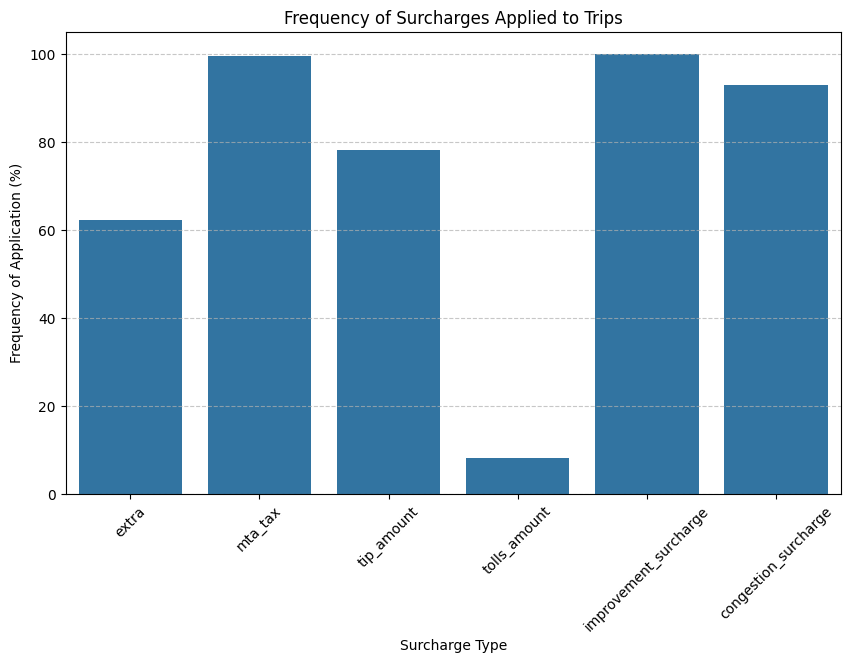

In [167]:
# visualize frequency of surcharges applied
plt.figure(figsize=(10, 6))
sns.barplot(x=surcharge_freq.index, y=surcharge_freq.values)
plt.xlabel('Surcharge Type')
plt.ylabel('Frequency of Application (%)')
plt.title('Frequency of Surcharges Applied to Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

The analysis reveals that passenger demand varies significantly across time and days. Evening and night hours, particularly on weekends, show higher activity and increased passenger counts, indicating leisure and group travel. In contrast, morning and afternoon periods are dominated by individual commuters, resulting in lower passenger counts and more transactional trips.

Recommendations:
<ol>
<li>Increase cab availability during evening and night hours, especially on weekends.</li>
<li>Use dynamic routing to avoid congestion heavy zones during peak hours.</li>
<li>Prioritize dispatching in high-demand zones, while allocating more vehicles near airports, transit hubs, and busy commercial areas.</li>
<li>Reposition cabs from low-demand to high-demand zones in real time to reduce idle time.</li>
</ol>

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Passenger count varies across zones, with residential areas exhibiting higher average passenger counts, suggesting family or group travel.
On the other hand, commercial and business districts show lower passenger count, reflecting predominantly solo travel.
 
Recommendations:
<ol>
<li>Position more cabs in residential zones during evenings/weekends.</li>
<li>Maintain availability in commercial zones during morning hours.
<li>Deploy cabs near entertainment areas at night for higher trip volumes.
<li>Place vehicles demand strategically near bridges and airports to capture toll-based trips.
</ol>

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Tipping behavior varies, with short trips showing higher average tip percentage but also inconsistent low-tip occurrences, while group rides generally leading to lower tips due to shared responsibility.
Additionally, surcharge patterns reveal that fixed charges are applied universally, whereas congestion and extra charges are more frequent during peak hours and in high-traffic zones.

Recommendations:
<ol>
<li>Implement dynamic pricing during peak hours to maximize revenue.
<li>Offer incentives or discounts during low-demand periods.
<li>Adjust pricing for long-distance travel to encourage tip percentages.
<li>Introduce group ride incentives to improve tipping and customer satisfaction.
<li>Optimize surcharge application by balancing competitiveness and profitability, especially in high congestion zones.
</ol>